In [2]:
import os

DATASET_PATH = r"C:\Users\94772\Desktop\Abdullah_project\Tamil_Character_Recognition\dataset_raw"

class_folders = sorted(os.listdir(DATASET_PATH))
print("Total Class Folders Found:", len(class_folders))

empty_classes = []
total_images = 0

for folder in class_folders:
    folder_path = os.path.join(DATASET_PATH, folder)
    if not os.path.isdir(folder_path):
        continue
    
    images = os.listdir(folder_path)
    if len(images) == 0:
        empty_classes.append(folder)
    total_images += len(images)

print("Total Images:", total_images)
print("Empty Folders:", empty_classes if empty_classes else "None")


Total Class Folders Found: 247
Total Images: 24947
Empty Folders: None


## EDA

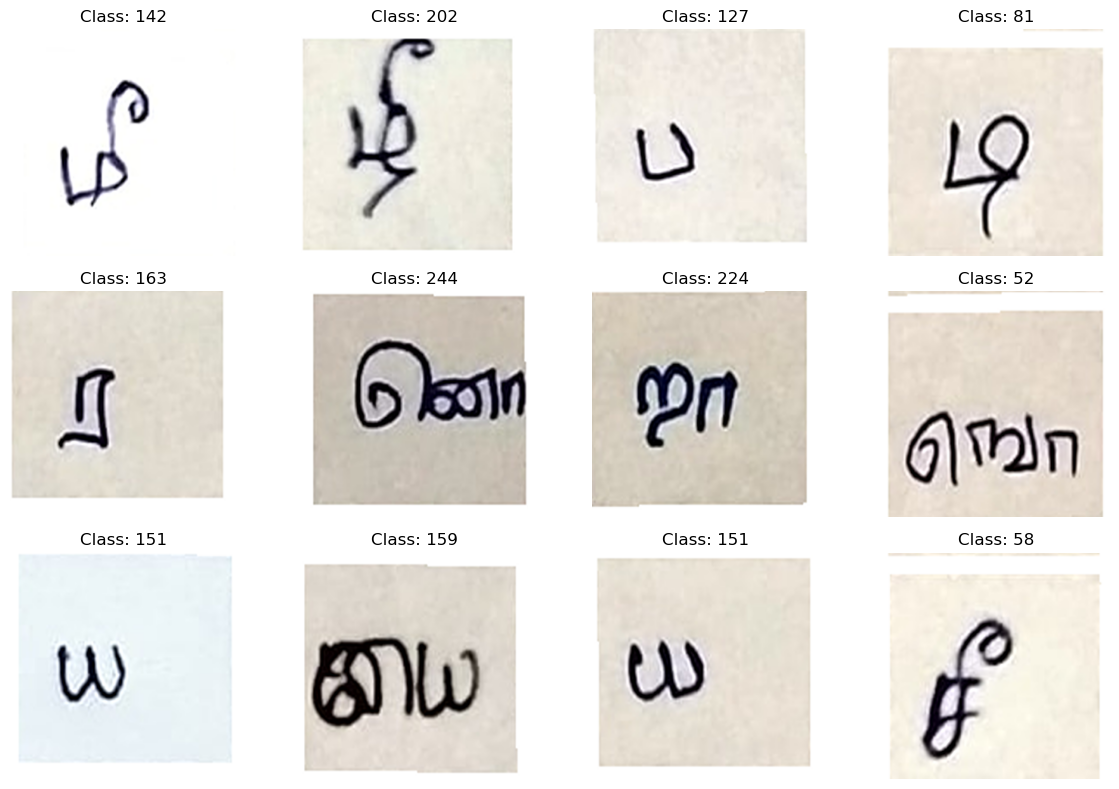

In [3]:
## Visualize Random Images
import os
import random
import matplotlib.pyplot as plt
from PIL import Image



folders = sorted(os.listdir(DATASET_PATH))

plt.figure(figsize=(12,8))

for i in range(12):
    folder = random.choice(folders)
    folder_path = os.path.join(DATASET_PATH, folder)
    img_name = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, img_name)

    img = Image.open(img_path)

    plt.subplot(3,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Class: {folder}")
    plt.axis("off")

plt.tight_layout()
plt.show()



In [ ]:
##Class Distribution

In [5]:
import pandas as pd

In [7]:
class_counts = {}

valid_ext = (".png", ".jpg", ".jpeg", ".bmp")

for folder in os.listdir(DATASET_PATH):
    path = os.path.join(DATASET_PATH, folder)
    images = [f for f in os.listdir(path) if f.lower().endswith(valid_ext)]
    class_counts[folder] = len(images)

import pandas as pd
df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
print(df.describe())

       Count
count  247.0
mean   100.0
std      0.0
min    100.0
25%    100.0
50%    100.0
75%    100.0
max    100.0


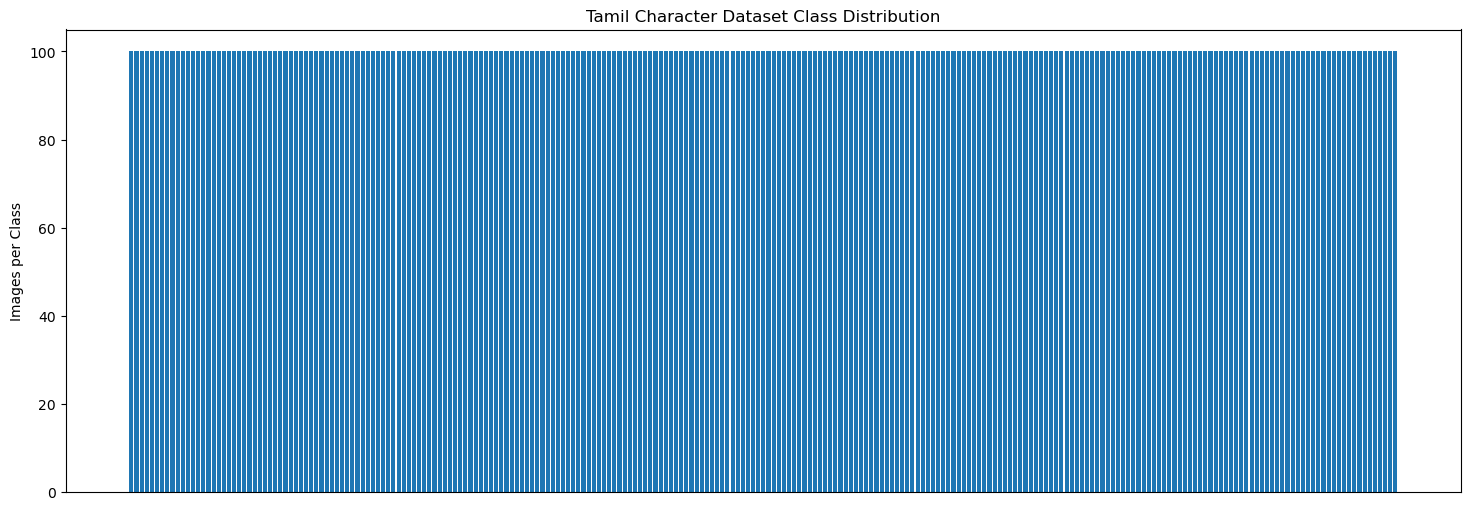

In [8]:
#Plot Distribution
plt.figure(figsize=(18,6))
plt.bar(df["Class"], df["Count"])
plt.xticks([], [])      # too many classes so hide labels
plt.ylabel("Images per Class")
plt.title("Tamil Character Dataset Class Distribution")
plt.show()


In [10]:
from PIL import Image
import os

widths = []
heights = []

valid_ext = (".png", ".jpg", ".jpeg", ".bmp")

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)

    # filter only image files
    images = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_ext)]
    
    if len(images) == 0:
        continue
    
    img_path = os.path.join(folder_path, images[0])  # take first image
    img = Image.open(img_path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

print("Unique Widths:", set(widths))
print("Unique Heights:", set(heights))


Unique Widths: {300}
Unique Heights: {300}


In [11]:
from PIL import Image
import os

valid_ext = (".png", ".jpg", ".jpeg", ".bmp")

sample_image = None

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    for f in os.listdir(folder_path):
        if f.lower().endswith(valid_ext):
            sample_image = Image.open(os.path.join(folder_path, f))
            break
    if sample_image:
        break

print("Image Mode:", sample_image.mode)


Image Mode: RGB


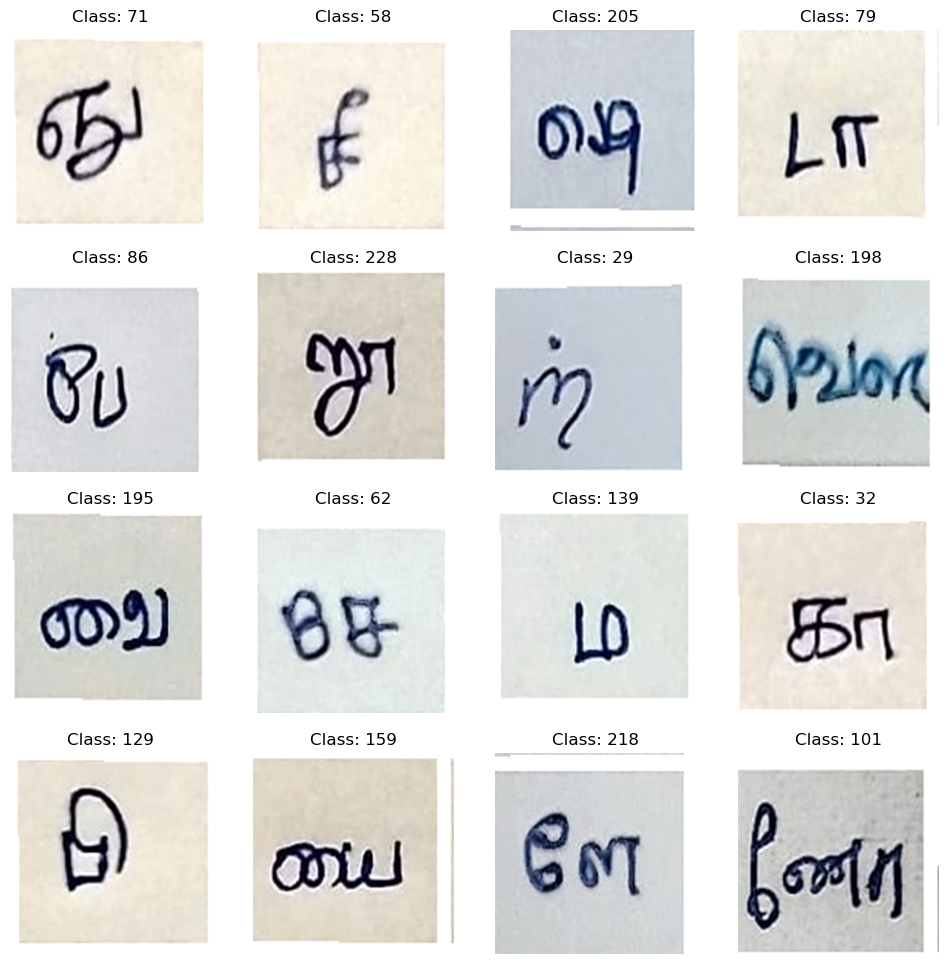

In [14]:
##Visualize sample images
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

valid_ext = (".png", ".jpg", ".jpeg", ".bmp")

folders = sorted(os.listdir(DATASET_PATH))

plt.figure(figsize=(12,12))

for i in range(16):
    folder = random.choice(folders)
    folder_path = os.path.join(DATASET_PATH, folder)

    images = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_ext)]
    img_path = os.path.join(folder_path, random.choice(images))

    img = Image.open(img_path)

    plt.subplot(4,4,i+1)
    plt.imshow(img)
    plt.title(f"Class: {folder}")
    plt.axis("off")

plt.show()
